In [11]:
import sys; 
sys.path.append('..') 

from src.io_utils import cargar_imagen, cargar_mascara, listar_pares_imagen_mascara 

from src.presegmentation import presegmentar_ventanas, presegmentar_superpixeles 

import matplotlib.pyplot as plt

In [12]:
pares = listar_pares_imagen_mascara('../data/raw/train', '../data/masks/train') 

ruta_img, ruta_mask = pares[0] 
imagen = cargar_imagen(ruta_img) 
mascara = cargar_mascara(ruta_mask) 

In [13]:
pares[0]

('../data/raw/train/ISIC_0000000.jpg',
 '../data/masks/train/ISIC_0000000_Segmentation.png')

In [14]:
import numpy as np
with open('imagen.txt', 'w') as f:
    for fila in imagen:
        linea = ' '.join(f"({r},{g},{b})" for r, g, b in fila)
        f.write(linea + '\n')
    
with open('mascara.txt', 'w') as f:
    f.write(np.array2string(mascara, threshold=np.inf, max_line_width=np.inf))

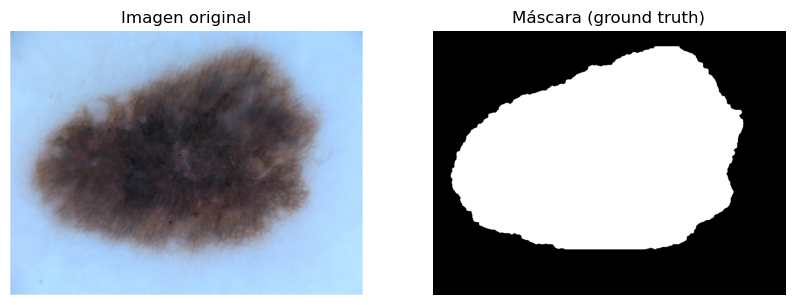

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5)) 
axes[0].imshow(imagen); axes[0].set_title('Imagen original'); axes[0].axis('off') 
axes[1].imshow(mascara, cmap='gray'); axes[1].set_title('Máscara (ground truth)'); axes[1].axis('off') 

plt.show() 

# Segmentación

In [16]:
from skimage.segmentation import mark_boundaries
import numpy as np

In [17]:
regiones_ventanas = presegmentar_ventanas(imagen, tam_ventana=32)
regiones_sp = presegmentar_superpixeles(imagen, n_segmentos=100)

In [18]:
regiones_sp

[array([[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(767, 1022)),
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(767, 1022)),
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
       

108
(767, 1022)
6731


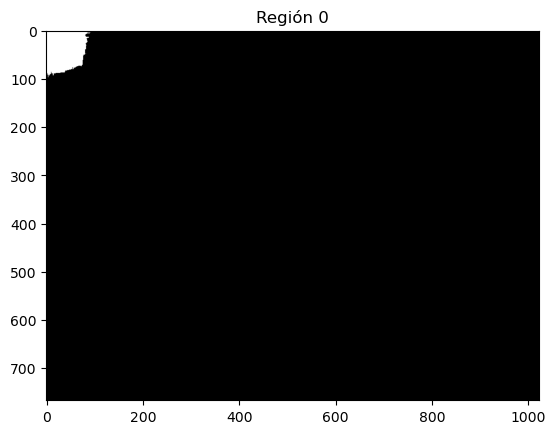

In [19]:
print(len(regiones_sp))           # cuántas regiones/superpíxeles hay
print(regiones_sp[0].shape)       # confirma que cada una es (767, 1022)
print(regiones_sp[0].sum())       # cuántos pixeles True tiene esta región (su "tamaño")

plt.imshow(regiones_sp[0], cmap='gray')  # visualiza solo esa región — verás una manchita blanca donde está ese superpíxel
plt.title('Región 0')
plt.show()

In [22]:
# Reconstruye las etiquetas de superpíxeles para dibujar los contornos
etiquetas = np.zeros(imagen.shape[:2], dtype=int)
for i, region in enumerate(regiones_sp):
    etiquetas[region] = i

In [23]:
with open('etiquetas.txt', 'w') as f:
    f.write(np.array2string(etiquetas, threshold=np.inf, max_line_width=np.inf))

In [24]:
print(etiquetas.shape)                    # (767, 1022) — confirma que es 2D
print(np.unique(etiquetas))               # [0, 1, 2, ..., 107] — las 108 categorías
print(np.unique(etiquetas).size)          # 108 — cuántos superpíxeles distintos hay

(767, 1022)
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107]
108


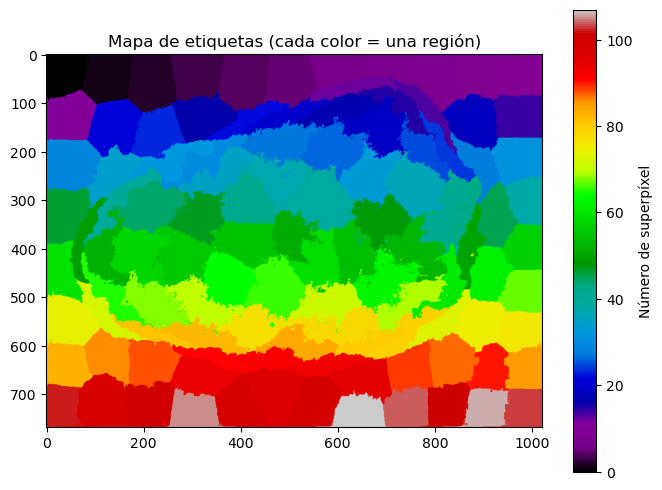

In [25]:
plt.figure(figsize=(8, 6))
plt.imshow(etiquetas, cmap='nipy_spectral')
plt.colorbar(label='Número de superpíxel')
plt.title('Mapa de etiquetas (cada color = una región)')
plt.show()

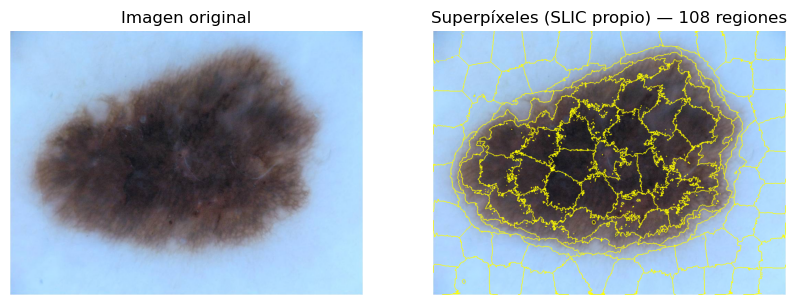

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(imagen)
axes[0].set_title('Imagen original')
axes[0].axis('off')

axes[1].imshow(mark_boundaries(imagen, etiquetas))
axes[1].set_title(f'Superpíxeles (SLIC propio) — {len(regiones_sp)} regiones')
axes[1].axis('off')

plt.show()